# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.
* **Input**:
  * class_distribution.csv
  * results.zip - a compressed archive containing the layered and prepared dataset for training (train, test, val)
    * each file in these folders represents a *processed sleep window* (epoch)
* **Output:**
  * `model_bilstm_baseline.pt`
  * `model_crnn.pt`
  * `model_resnet.pt`

# Imports

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
import tensorflow as tf
import os
import warnings

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", message="X has feature names")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

I0000 00:00:1779715366.981199  411649 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779715367.043510  411649 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779715368.356467  411649 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
test_path_csv = 'process_dataset/extracted_features/test_features.csv'
test_path_raw = 'process_dataset/test'

class_distribution_path = 'process_dataset/class_distribution_train.csv'

model_paths = {
    'LightGBM':'models/best_LGBM_calibrated.pkl',
    'XGBoost':'models/best_XGB_calibrated.pkl',
    'RandomForest':'models/best_RF_calibrated.pkl',
    'LogisticRegession':'models/best_LogisticR-Baseline.pkl',
    'LDA':'models/best_LDA-Baseline.pkl',
    'MLP':'models/best_mlp.keras',
    'LSTM':'models/best_lstm_se_focal.keras',
    'ResNet':'models/best_resnet_feature.keras'#,
    # 'CNN':'http://10.66.7.79:8888/lab/tree/models/best_medium_cnn.keras'
}

# Functions

In [20]:
def evaluate_model(y_true, y_pred, class_names=['Wake', 'N1', 'N2', 'N3', 'REM']):
    '''
    Evaluate the performance of a classification model.

    Parameters:
      - y_true (array-like): True labels.
      - y_pred (array-like): Predicted labels.
      - class_names (list): List of class names.
    '''
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"Accuracy {acc:.4f}\n")
    print("Cohen's Kappa:", kappa)

    print("--- Classification report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    
    return acc, kappa

In [ ]:
def build_sequences_per_subject(df, feature_cols, label_col='Label', subject_col='Subject_ID', seq_len=30, step=5):
    X_seq, y_seq, subj_seq = [], [], []
    for subj, group in df.groupby(subject_col):
        group = group.sort_index()
        feats = group[feature_cols].values
        labels = group[label_col].values
        for i in range(0, len(feats) - seq_len, step):
            X_seq.append(feats[i:i+seq_len])
            y_seq.append(labels[i+seq_len-1])
            subj_seq.append(subj)
    return np.array(X_seq), np.array(y_seq), np.array(subj_seq)

In [5]:
def se_feature_attention(inputs, reduction=8):
    n = inputs.shape[-1]

    x = layers.Dense(n // reduction, activation='relu')(inputs)
    x = layers.Dense(n, activation='sigmoid')(x)

    return layers.Multiply()([inputs, x])

In [6]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce_term = -y_true_one_hot * tf.math.log(y_pred)
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_modulator = tf.pow(1. - p_t, gamma)
        focal_loss_per_class = tf.expand_dims(focal_modulator, axis=-1) * ce_term
        return tf.reduce_mean(tf.reduce_sum(alpha * focal_loss_per_class, axis=-1))
    return loss

# Dataset

In [7]:
df_test = pd.read_csv(test_path_csv)

cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_test.columns if c not in cols_to_drop]

X_test = df_test[feature_cols]
y_test = df_test['Label']

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.fillna(0))

X_test_seq, y_test_seq, _ = build_sequences_per_subject(df_test, feature_cols, seq_len=30, step=5)

# Models test

In [23]:
result_vals = {}

## LightGBM

Accuracy 0.7811

Cohen's Kappa: 0.694964806891643
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



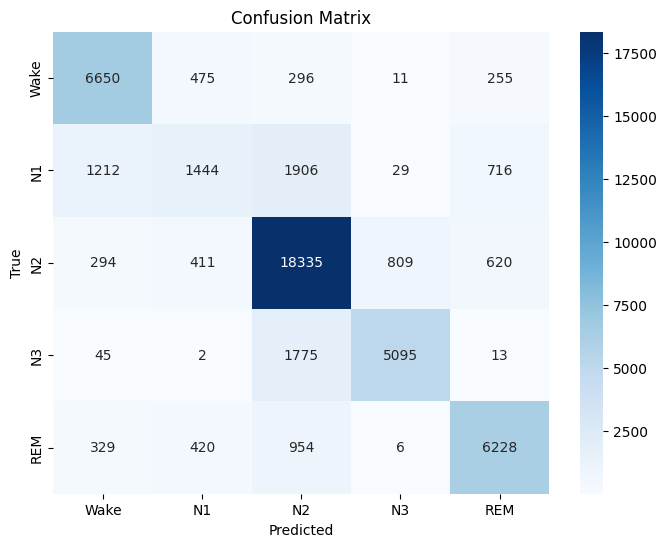

In [24]:
lgb_model = joblib.load(model_paths['LightGBM'])

# Predict calibrated probabilities
y_proba_test = lgb_model.predict_proba(X_test)

# Predict final class
y_pred_test_lgm = lgb_model.predict(X_test)

acc, kappa = evaluate_model(y_test, y_pred_test_lgm)
result_vals['LGBM']= [acc, kappa]

## XGBoost

Accuracy 0.7804

Cohen's Kappa: 0.6943225033954341
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.86      0.82      7687
          N1       0.52      0.28      0.36      5307
          N2       0.79      0.89      0.84     20469
          N3       0.85      0.73      0.79      6930
         REM       0.79      0.79      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



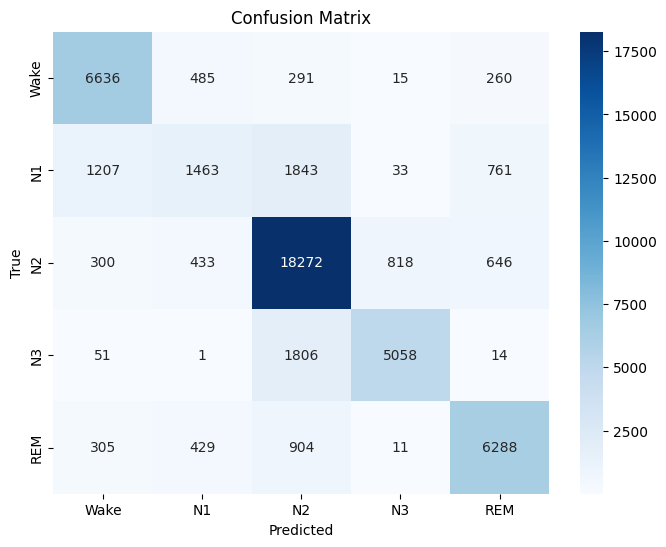

In [ ]:
xgb_model = joblib.load(model_paths['XGBoost'])

y_proba_test = xgb_model.predict_proba(X_test)

y_pred_test_xgb = xgb_model.predict(X_test)

acc, kappa = evaluate_model(y_test, y_pred_test_xgb)
result_vals['XGB']= [acc, kappa]

## Random Forest

Accuracy 0.7523

Cohen's Kappa: 0.6557300761808108
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.72      0.82      0.77      7687
          N1       0.49      0.24      0.32      5307
          N2       0.78      0.87      0.82     20469
          N3       0.85      0.70      0.77      6930
         REM       0.74      0.79      0.76      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.68      0.69     48330
weighted avg       0.74      0.75      0.74     48330



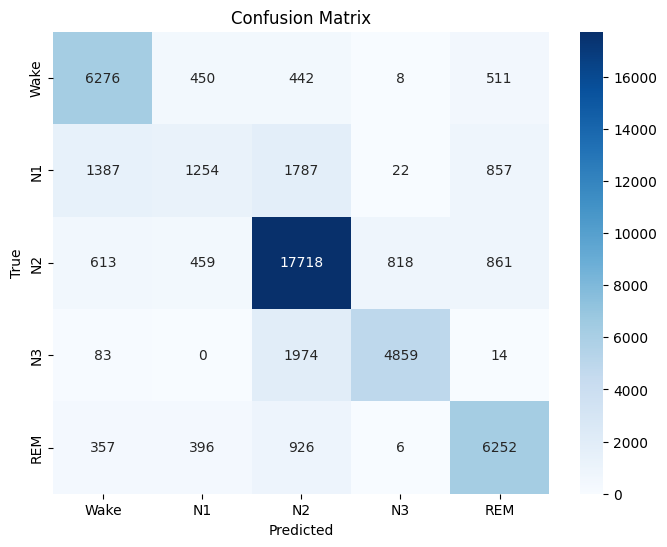

In [ ]:
rf_model = joblib.load(model_paths['RandomForest'])

y_proba_test = rf_model.predict_proba(X_test)

y_pred_test_rf = rf_model.predict(X_test)

acc, kappa = evaluate_model(y_test, y_pred_test_rf)
result_vals['RF']= [acc, kappa]

## LDA

Accuracy 0.7352

Cohen's Kappa: 0.633819693313449
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.72      0.74      7687
          N1       0.41      0.31      0.35      5307
          N2       0.77      0.85      0.81     20469
          N3       0.79      0.69      0.74      6930
         REM       0.72      0.79      0.75      7937

    accuracy                           0.74     48330
   macro avg       0.69      0.67      0.68     48330
weighted avg       0.73      0.74      0.73     48330



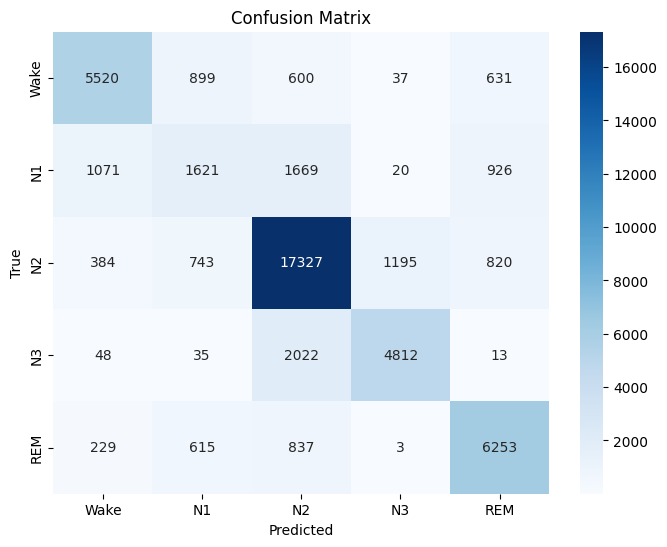

In [ ]:
lda_model = joblib.load(model_paths['LDA'])

y_proba_test = lda_model.predict_proba(X_test_scaled)

y_pred_test_lda = lda_model.predict(X_test_scaled)

acc, kappa = evaluate_model(y_test, y_pred_test_lda)
result_vals['LDA']= [acc, kappa]

## Logistic Regression

Accuracy 0.7213

Cohen's Kappa: 0.6319456980956805
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



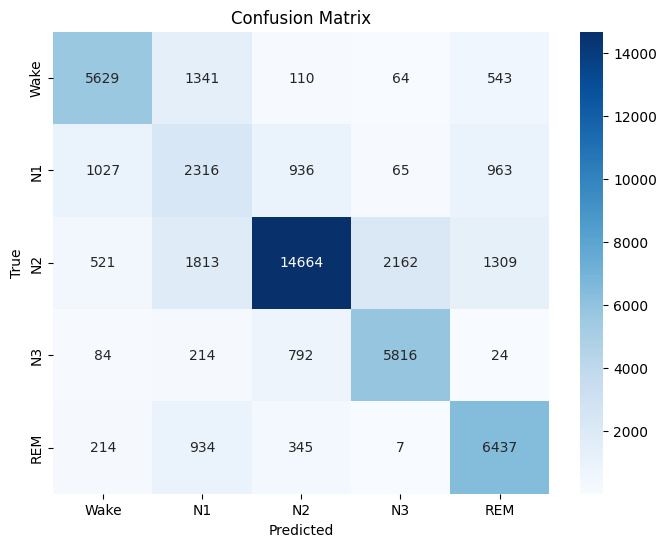

In [ ]:
lr_model = joblib.load(model_paths['LogisticRegession'])

y_proba_test = lr_model.predict_proba(X_test_scaled)

y_pred_test_lr = lr_model.predict(X_test_scaled)

acc, kappa = evaluate_model(y_test, y_pred_test_lr)
result_vals['LR']= [acc, kappa]

## MLP

1511/1511 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy 0.7817

Cohen's Kappa: 0.6992646406590963
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.50      0.34      0.40      5307
          N2       0.81      0.87      0.84     20469
          N3       0.83      0.75      0.79      6930
         REM       0.79      0.81      0.80      7937

    accuracy                           0.78     48330
   macro avg       0.74      0.73      0.73     48330
weighted avg       0.77      0.78      0.77     48330



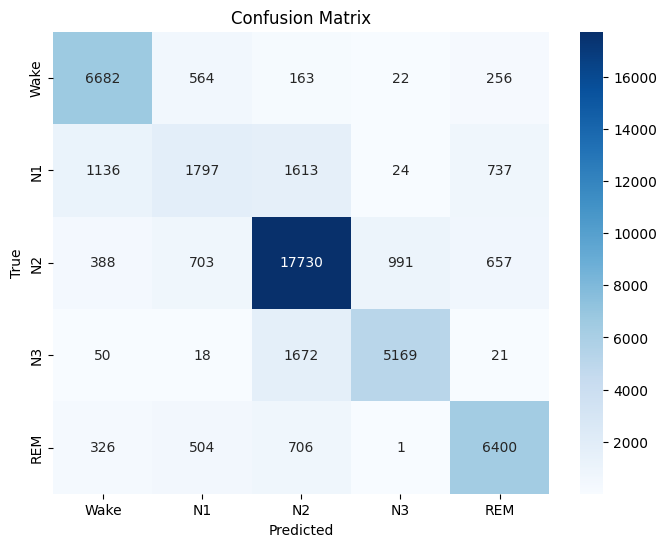

In [ ]:
mlp_model = load_model(model_paths['MLP'])

y_proba_mlp = mlp_model.predict(X_test)
y_pred_test_mlp = y_proba_mlp.argmax(axis=1)

acc, kappa = evaluate_model(y_test, y_pred_test_mlp)
result_vals['MLP']= [acc, kappa]

## LSTM

292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Accuracy 0.7869

Cohen's Kappa: 0.7050810033948228
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.80      0.86      0.83      1395
          N1       0.50      0.27      0.35       977
          N2       0.81      0.86      0.83      3996
          N3       0.80      0.77      0.79      1387
         REM       0.80      0.87      0.84      1585

    accuracy                           0.79      9340
   macro avg       0.74      0.73      0.73      9340
weighted avg       0.77      0.79      0.78      9340



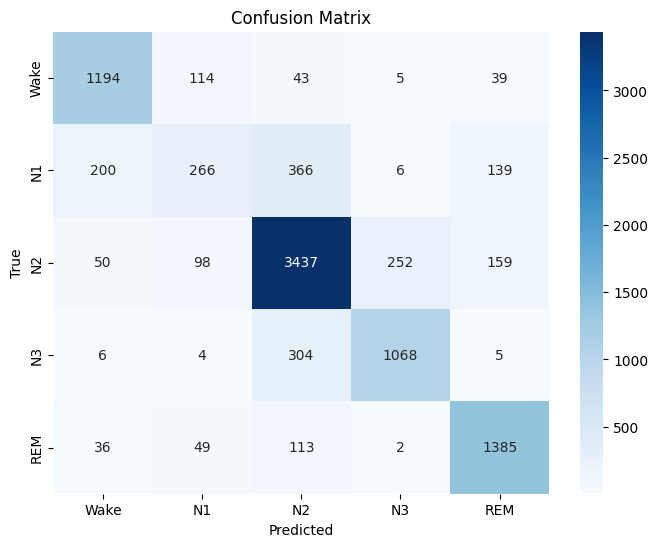

In [ ]:
lstm_model = load_model(
    model_paths['LSTM'],
    custom_objects={
        "se_feature_attention": se_feature_attention,
        "focal_loss": focal_loss
    },
    compile=False
)

y_proba_lstm = lstm_model.predict(X_test_seq)
y_pred_test_lstm = y_proba_lstm.argmax(axis=1)

acc, kappa = evaluate_model(y_test_seq, y_pred_test_lstm)
result_vals['LSTM']= [acc, kappa]

## ResNet

292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Accuracy 0.7915

Cohen's Kappa: 0.7101238122575154
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.85      0.83      1395
          N1       0.52      0.27      0.35       977
          N2       0.80      0.88      0.84      3996
          N3       0.81      0.80      0.81      1387
         REM       0.82      0.84      0.83      1585

    accuracy                           0.79      9340
   macro avg       0.75      0.73      0.73      9340
weighted avg       0.78      0.79      0.78      9340



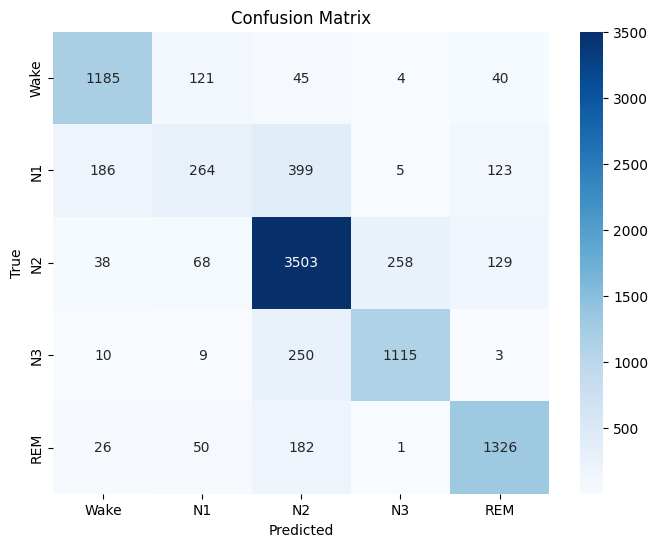

In [ ]:
resnet_model = load_model(model_paths['ResNet'], compile=False)

y_proba_resnet = resnet_model.predict(X_test_seq)
y_pred_test_resnet = y_proba_resnet.argmax(axis=1)

acc, kappa = evaluate_model(y_test_seq, y_pred_test_resnet)
result_vals['RN']= [acc, kappa]

# View

In [37]:
print(result_vals)

{'LGBM': [0.7811297330850403, 0.694964806891643], 'XGB': [0.7804055452100145, 0.6943225033954341], 'RF': [0.752307055659011, 0.6557300761808108], 'LDA': [0.7352162218084006, 0.633819693313449], 'lr': [0.7213325056900476, 0.6319456980956805], 'LR': [0.7213325056900476, 0.6319456980956805], 'MLP': [0.7816677012207739, 0.6992646406590963], 'LSTM': [0.7869379014989293, 0.7050810033948228], 'RN': [0.7915417558886509, 0.7101238122575154]}


In [49]:
# result_vals = {'LGBM': [0.7811297330850403, 0.694964806891643], 'XGB': [0.7804055452100145, 0.6943225033954341], 'RF': [0.752307055659011, 0.6557300761808108], 'LDA': [0.7352162218084006, 0.633819693313449], 'lr': [0.7213325056900476, 0.6319456980956805], 'LR': [0.7213325056900476, 0.6319456980956805], 'MLP': [0.7816677012207739, 0.6992646406590963], 'LSTM': [0.7869379014989293, 0.7050810033948228], 'RN': [0.7915417558886509, 0.7101238122575154]}

sorted_models = sorted(result_vals.items(), key=lambda x: x[1][0], reverse=True)
sorted_models

[('RN', [0.7915417558886509, 0.7101238122575154]),
 ('LSTM', [0.7869379014989293, 0.7050810033948228]),
 ('MLP', [0.7816677012207739, 0.6992646406590963]),
 ('LGBM', [0.7811297330850403, 0.694964806891643]),
 ('XGB', [0.7804055452100145, 0.6943225033954341]),
 ('RF', [0.752307055659011, 0.6557300761808108]),
 ('LDA', [0.7352162218084006, 0.633819693313449]),
 ('lr', [0.7213325056900476, 0.6319456980956805]),
 ('LR', [0.7213325056900476, 0.6319456980956805])]

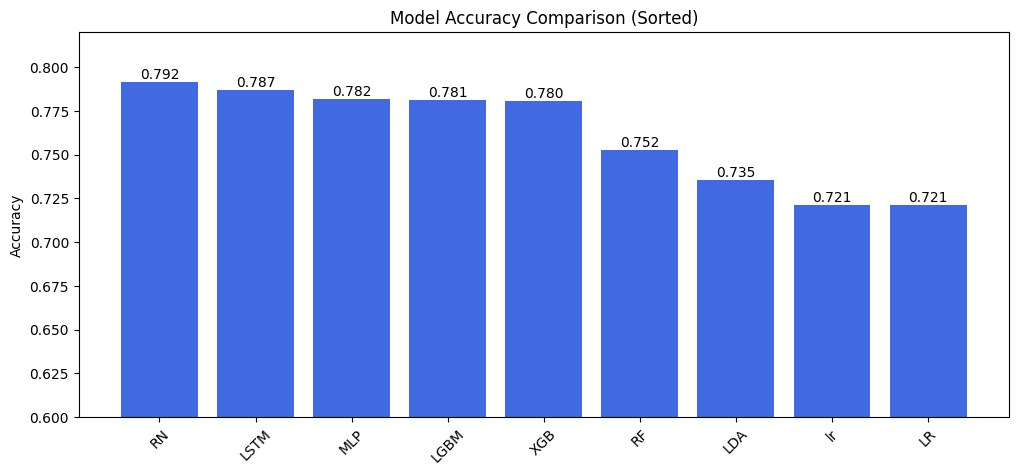

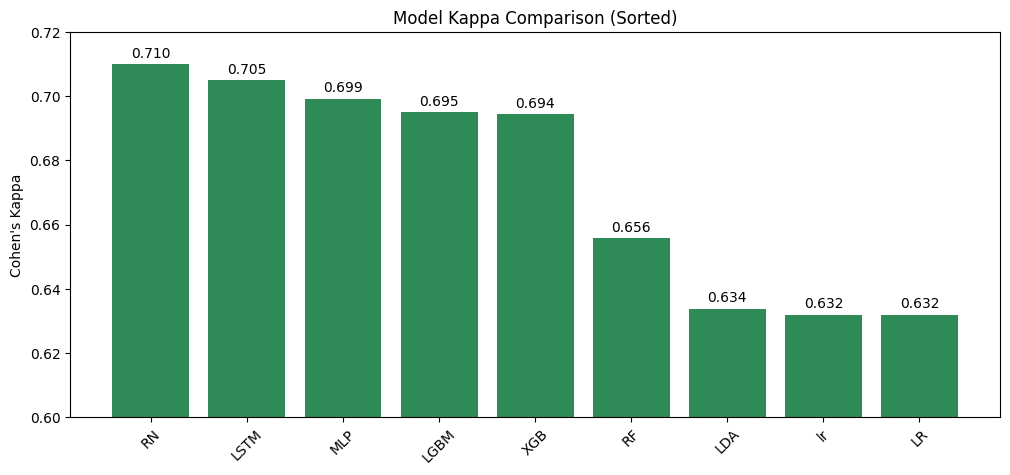

In [ ]:
labels     = [m[0]     for m in sorted_models]
accuracies = [m[1][0]  for m in sorted_models]
kappas     = [m[1][1]  for m in sorted_models]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(labels, accuracies, color="royalblue")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Sorted)")
plt.ylim(0.6, 0.82)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

plt.figure(figsize=(12,5))
plt.bar(labels, kappas, color="seagreen")
plt.xticks(rotation=45)
plt.ylabel("Cohen's Kappa")
plt.title("Model Kappa Comparison (Sorted)")
plt.ylim(0.6, 0.72)

for i, v in enumerate(kappas):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()


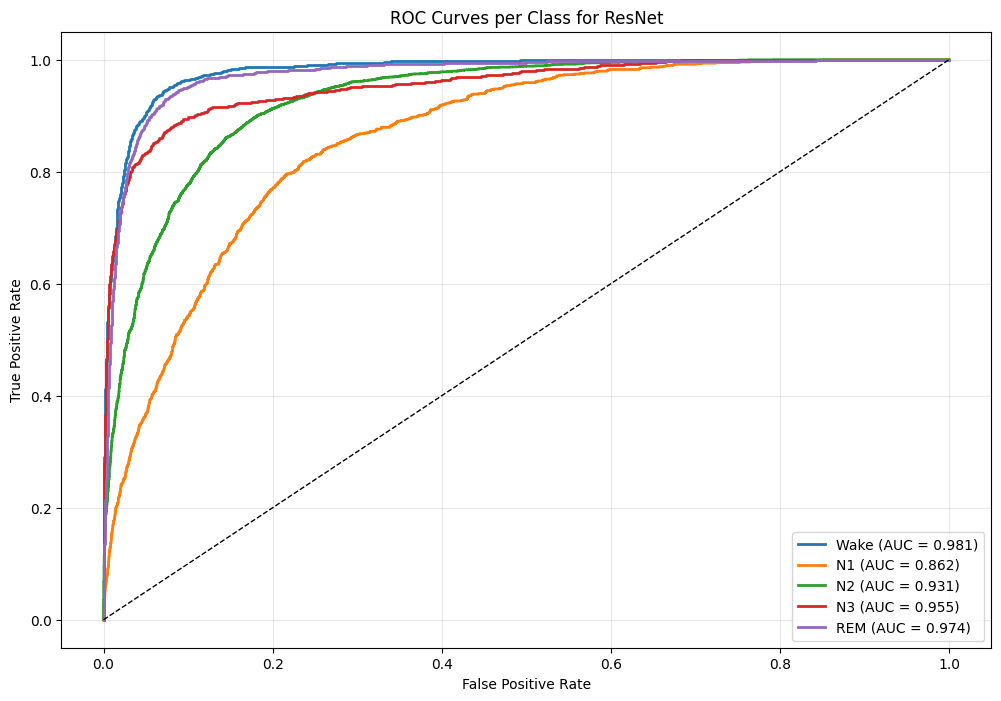

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_per_class(y_true, y_proba, model_name, class_names=None):
    if class_names is None:
        class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

    n_classes = len(class_names)

    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(12, 8))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2,
                 label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves per Class for {model_name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_per_class(y_test_seq, y_proba_resnet,"ResNet")